### MaritimeFlowX: A Spatial-Temporal Network Framework for Global Shipping Dynamics, Risk, and Sustainability

Author: Md Khadem Ali  

----------------------------------------------------------

PROJECT OVERVIEW:

This project models and analyzes the global maritime shipping network
using GIS-based spatial data and network science techniques. It focuses on understanding international trade connectivity, cargo flow patterns, and the structural importance of global ports.



In [4]:
!pip install networkx folium plotly python-louvain -q

In [5]:
import pandas as pd
import numpy as np

import networkx as nx

import matplotlib.pyplot as plt

import folium

import plotly.graph_objects as go

from networkx.algorithms.community import greedy_modularity_communities

plt.style.use('ggplot')

In [6]:
ports = pd.DataFrame({

'Port':[
'Singapore',
'Shanghai',
'Rotterdam',
'Dubai',
'Los Angeles',
'Hamburg',
'Busan',
'Chittagong',
'Mumbai',
'Hong Kong'
],

'Lat':[
1.3521,
31.2304,
51.9244,
25.2048,
34.0522,
53.5511,
35.1796,
22.3569,
19.0760,
22.3193
],

'Lon':[
103.8198,
121.4737,
4.4777,
55.2708,
-118.2437,
9.9937,
129.0756,
91.7832,
72.8777,
114.1694
]

})

ports

,Port,Lat,Lon
0,Singapore,1.3521,103.8198
1,Shanghai,31.2304,121.4737
2,Rotterdam,51.9244,4.4777
3,Dubai,25.2048,55.2708
4,Los Angeles,34.0522,-118.2437
5,Hamburg,53.5511,9.9937
6,Busan,35.1796,129.0756
7,Chittagong,22.3569,91.7832
8,Mumbai,19.0760,72.8777
9,Hong Kong,22.3193,114.1694


In [7]:
routes = pd.DataFrame({

'Source':[
'Singapore',
'Singapore',
'Shanghai',
'Dubai',
'Rotterdam',
'Hamburg',
'Busan',
'Chittagong',
'Mumbai',
'Hong Kong'
],

'Target':[
'Shanghai',
'Dubai',
'Busan',
'Rotterdam',
'Hamburg',
'Los Angeles',
'Los Angeles',
'Singapore',
'Dubai',
'Shanghai'
],

'Cargo_TEU':[
12000,
10000,
9000,
8500,
7500,
6000,
7000,
5000,
5500,
8000
]

})

routes

,Source,Target,Cargo_TEU
0,Singapore,Shanghai,12000
1,Singapore,Dubai,10000
2,Shanghai,Busan,9000
3,Dubai,Rotterdam,8500
4,Rotterdam,Hamburg,7500
5,Hamburg,Los Angeles,6000
6,Busan,Los Angeles,7000
7,Chittagong,Singapore,5000
8,Mumbai,Dubai,5500
9,Hong Kong,Shanghai,8000


In [8]:
G = nx.Graph()

for _, row in routes.iterrows():

    G.add_edge(
        row['Source'],
        row['Target'],
        weight=row['Cargo_TEU']
    )

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 10
Edges: 10


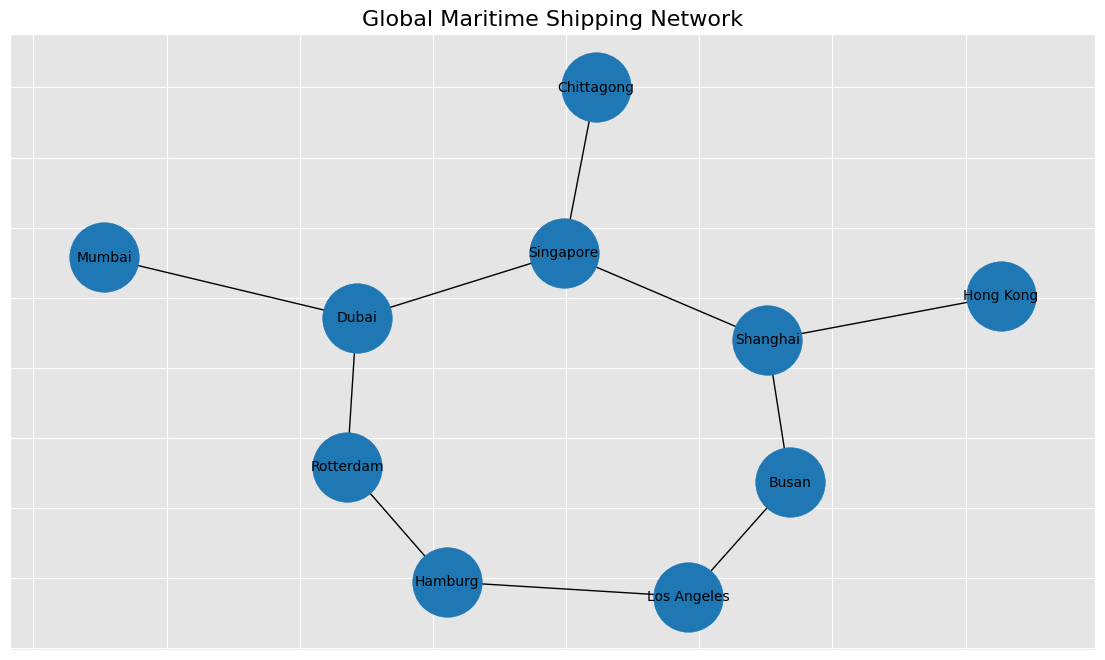

In [9]:
plt.figure(figsize=(14,8))

pos = nx.spring_layout(
    G,
    seed=42
)

nx.draw_networkx(
    G,
    pos,
    node_size=2500,
    font_size=10
)

plt.title(
    "Global Maritime Shipping Network",
    fontsize=16
)

plt.show()

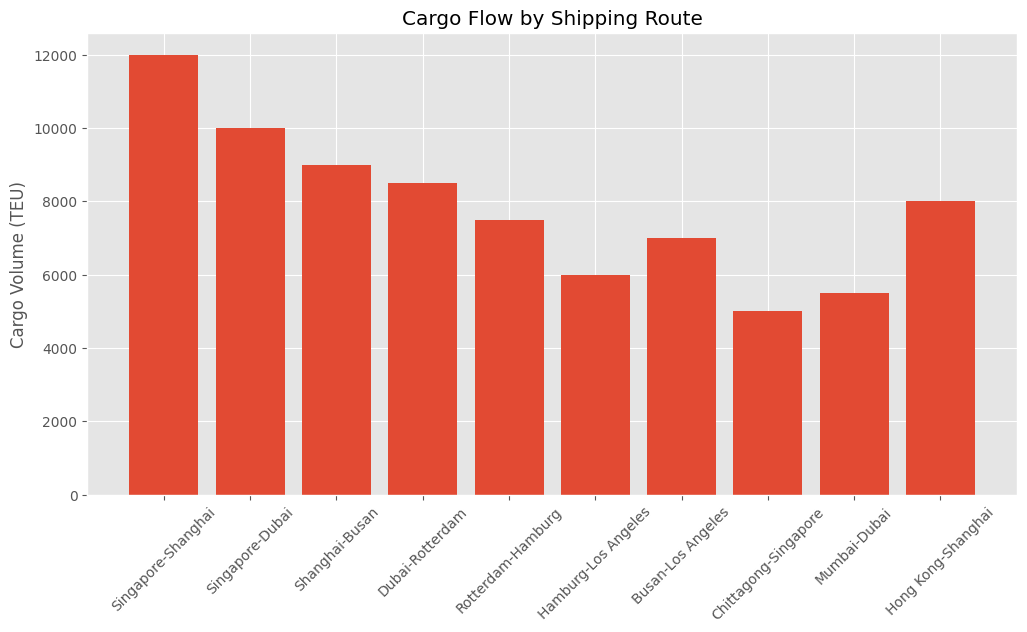

In [10]:
plt.figure(figsize=(12,6))

plt.bar(
    range(len(routes)),
    routes['Cargo_TEU']
)

plt.xticks(
    range(len(routes)),
    routes['Source'] + "-" + routes['Target'],
    rotation=45
)

plt.ylabel("Cargo Volume (TEU)")
plt.title("Cargo Flow by Shipping Route")

plt.show()

In [11]:
degree = nx.degree_centrality(G)

degree_df = pd.DataFrame(
    degree.items(),
    columns=['Port','Centrality']
)

degree_df = degree_df.sort_values(
    'Centrality',
    ascending=False
)

degree_df

,Port,Centrality
0,Singapore,0.333333
1,Shanghai,0.333333
2,Dubai,0.333333
3,Busan,0.222222
4,Rotterdam,0.222222
5,Hamburg,0.222222
6,Los Angeles,0.222222
7,Chittagong,0.111111
8,Mumbai,0.111111
9,Hong Kong,0.111111


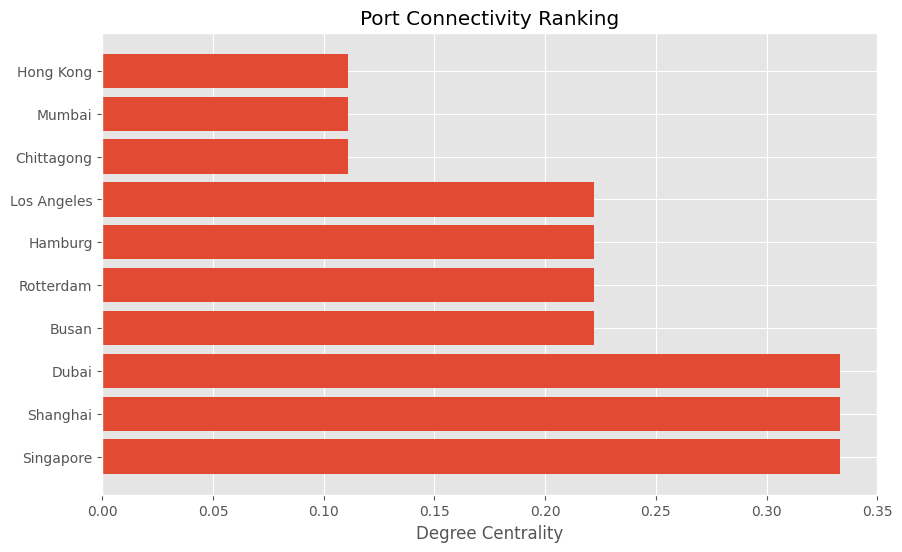

In [12]:
plt.figure(figsize=(10,6))

plt.barh(
    degree_df['Port'],
    degree_df['Centrality']
)

plt.title(
    "Port Connectivity Ranking"
)

plt.xlabel(
    "Degree Centrality"
)

plt.show()

In [13]:
# ==========================================
# Betweenness Centrality
# ==========================================

betweenness = nx.betweenness_centrality(G)

bet_df = pd.DataFrame(
    betweenness.items(),
    columns=['Port','Betweenness']
)

bet_df = bet_df.sort_values(
    'Betweenness',
    ascending=False
)

bet_df

,Port,Betweenness
0,Singapore,0.444444
1,Shanghai,0.388889
2,Dubai,0.388889
3,Busan,0.166667
4,Rotterdam,0.166667
5,Hamburg,0.111111
6,Los Angeles,0.111111
7,Chittagong,0.000000
8,Mumbai,0.000000
9,Hong Kong,0.000000


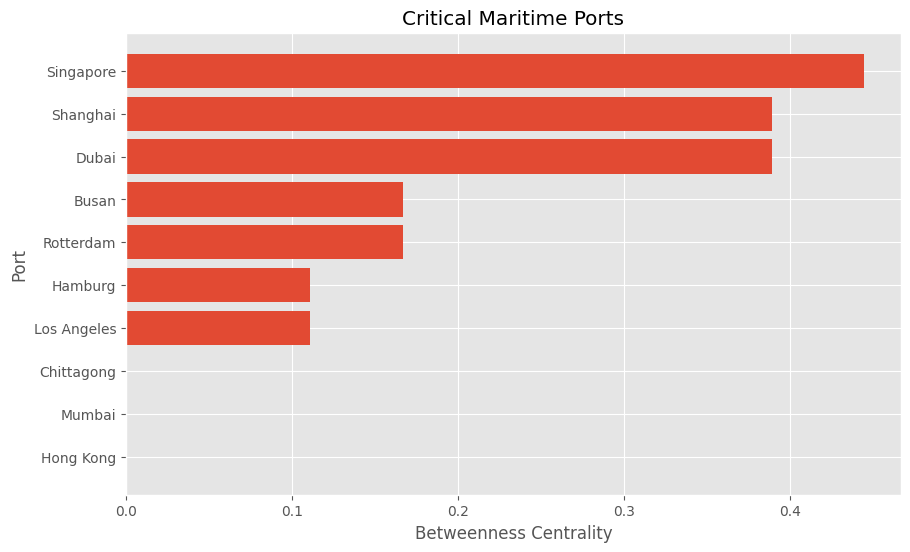

In [14]:
plt.figure(figsize=(10,6))

plt.barh(
    bet_df['Port'],
    bet_df['Betweenness']
)

plt.xlabel("Betweenness Centrality")
plt.ylabel("Port")

plt.title(
    "Critical Maritime Ports"
)

plt.gca().invert_yaxis()

plt.show()

In [15]:
# ==========================================
# Community Detection
# ==========================================

communities = list(
    greedy_modularity_communities(G)
)

for i, community in enumerate(communities):

    print(
        f"Cluster {i+1}:",
        list(community)
    )

Cluster 1: ['Busan', 'Shanghai', 'Los Angeles', 'Hong Kong']
Cluster 2: ['Dubai', 'Mumbai', 'Rotterdam', 'Hamburg']
Cluster 3: ['Singapore', 'Chittagong']


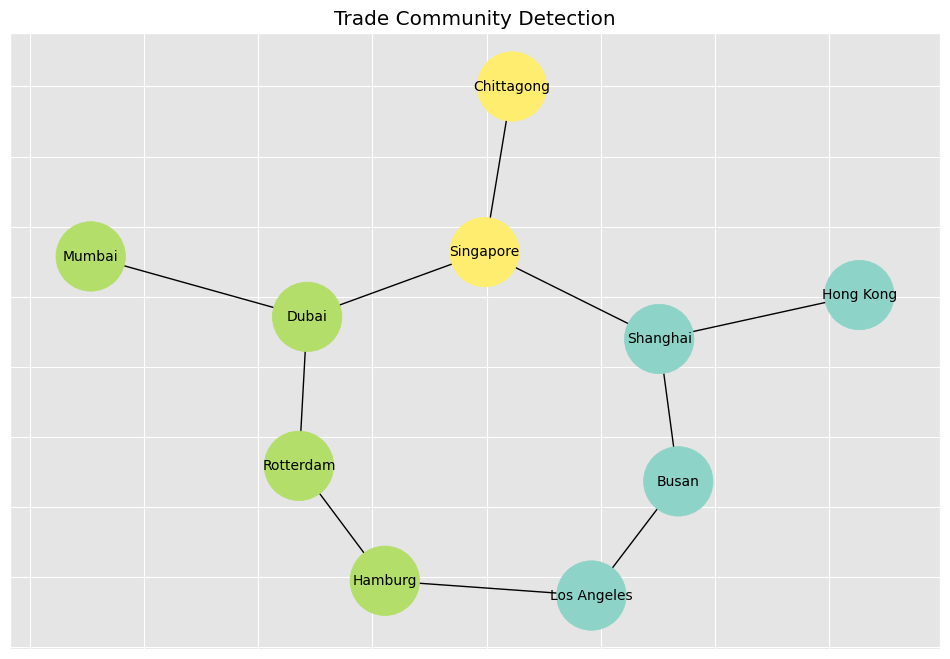

In [16]:
plt.figure(figsize=(12,8))

colors = {}

for i, community in enumerate(communities):

    for node in community:

        colors[node] = i

node_colors = [
    colors[node]
    for node in G.nodes()
]

pos = nx.spring_layout(
    G,
    seed=42
)

nx.draw_networkx(
    G,
    pos,
    node_color=node_colors,
    cmap=plt.cm.Set3,
    node_size=2500,
    font_size=10
)

plt.title(
    "Trade Community Detection"
)

plt.show()

In [17]:
ports_list = list(
    set(routes['Source'])
    .union(routes['Target'])
)

port_index = {
    port:i
    for i,port in enumerate(ports_list)
}

source = [
    port_index[x]
    for x in routes['Source']
]

target = [
    port_index[x]
    for x in routes['Target']
]

value = routes['Cargo_TEU']

fig = go.Figure(
    data=[
        go.Sankey(
            node=dict(
                label=ports_list
            ),
            link=dict(
                source=source,
                target=target,
                value=value
            )
        )
    ]
)

fig.update_layout(
    title_text="Global Maritime Cargo Flow",
    font_size=12
)

fig.show()

In [18]:
m = folium.Map(
    location=[25,30],
    zoom_start=2
)

for _, row in ports.iterrows():

    folium.Marker(
        location=[
            row['Lat'],
            row['Lon']
        ],
        popup=row['Port']
    ).add_to(m)

for _, row in routes.iterrows():

    start = ports[
        ports['Port']==row['Source']
    ].iloc[0]

    end = ports[
        ports['Port']==row['Target']
    ].iloc[0]

    folium.PolyLine(
        [
            [start['Lat'],start['Lon']],
            [end['Lat'],end['Lon']]
        ],
        weight=3
    ).add_to(m)

m

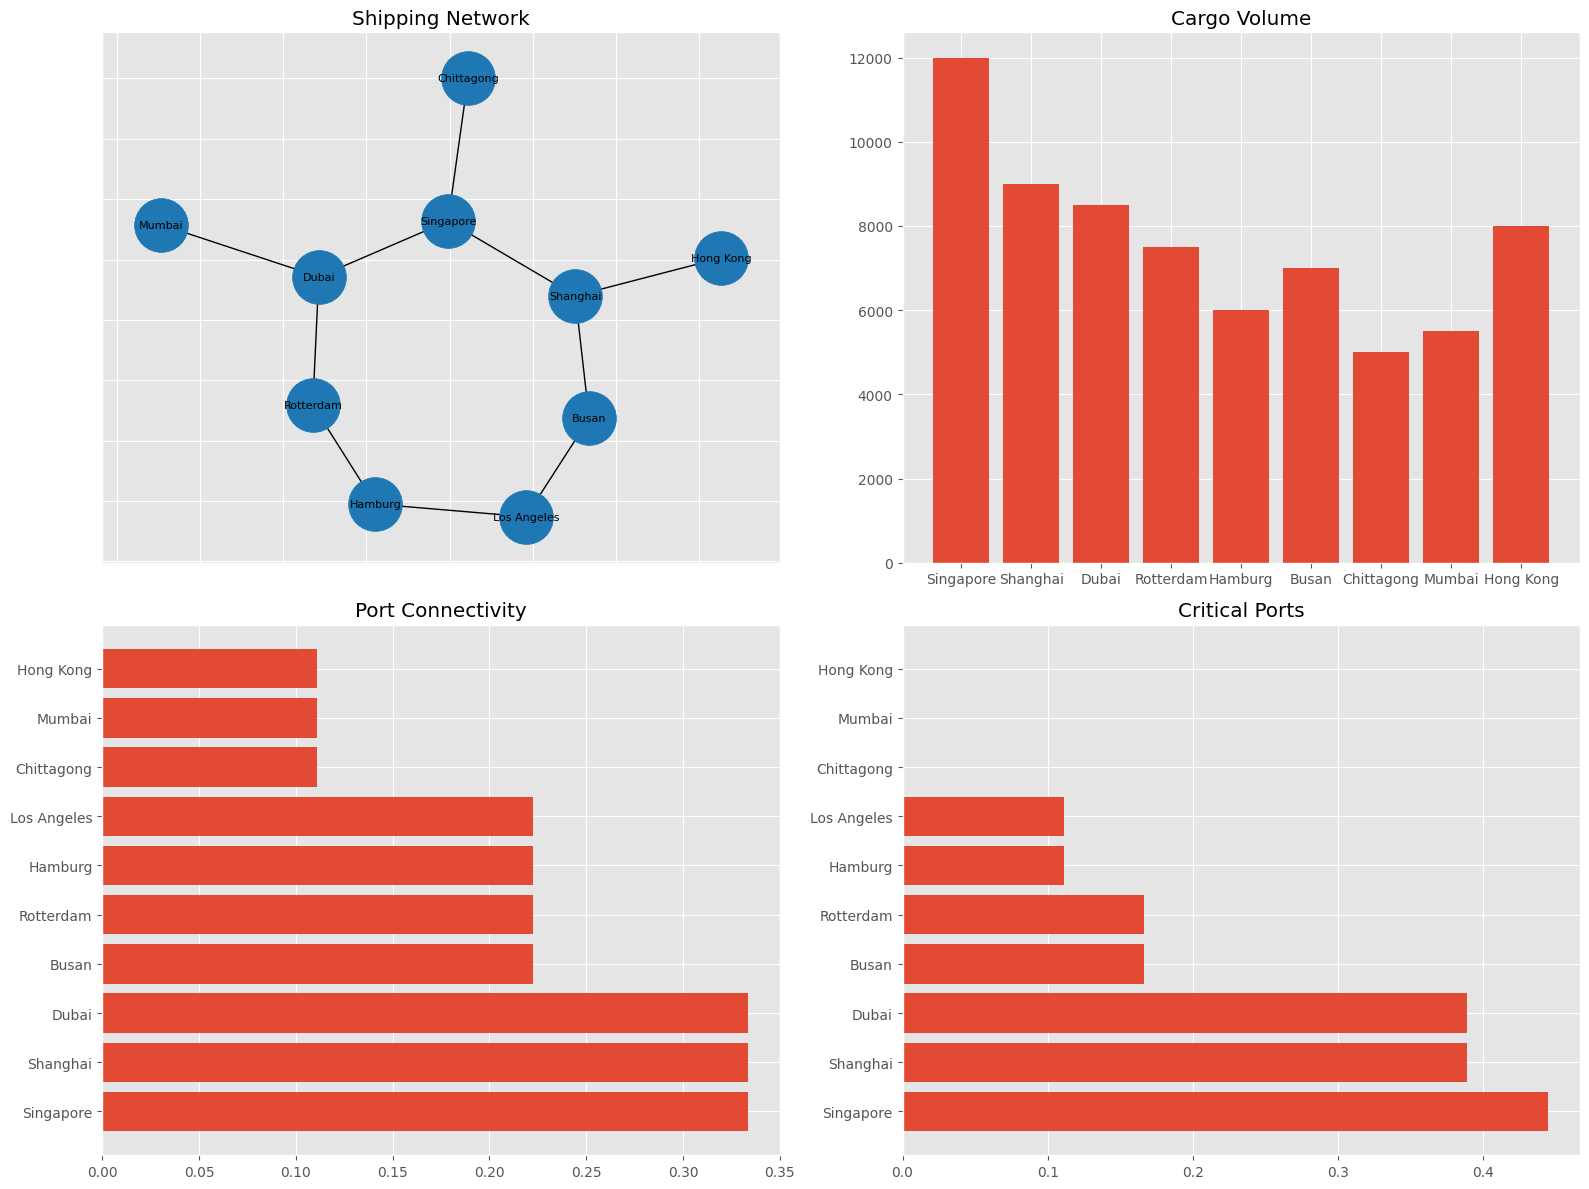

In [19]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(16,12)
)

# Network
nx.draw_networkx(
    G,
    pos,
    ax=axes[0,0],
    node_size=1500,
    font_size=8
)

axes[0,0].set_title(
    "Shipping Network"
)

# Cargo Flow
axes[0,1].bar(
    routes['Source'],
    routes['Cargo_TEU']
)

axes[0,1].set_title(
    "Cargo Volume"
)

# Degree Centrality
axes[1,0].barh(
    degree_df['Port'],
    degree_df['Centrality']
)

axes[1,0].set_title(
    "Port Connectivity"
)

# Betweenness
axes[1,1].barh(
    bet_df['Port'],
    bet_df['Betweenness']
)

axes[1,1].set_title(
    "Critical Ports"
)

plt.tight_layout()

plt.show()

In [20]:
path = nx.shortest_path(
    G,
    source='Chittagong',
    target='Los Angeles'
)

print(path)

['Chittagong', 'Singapore', 'Shanghai', 'Busan', 'Los Angeles']


In [21]:
ports['Congestion'] = np.random.randint(
    20,
    100,
    len(ports)
)

In [22]:
# ==========================================
# Carbon Emission Estimation
# ==========================================

routes['Distance_km'] = np.random.randint(
    3000,
    15000,
    len(routes)
)

routes['CO2_Tons'] = (
    routes['Distance_km']
    * routes['Cargo_TEU']
    * 0.00002
)

routes[['Source',
         'Target',
         'CO2_Tons']]

,Source,Target,CO2_Tons
0,Singapore,Shanghai,3533.76
1,Singapore,Dubai,605.20
2,Shanghai,Busan,2424.06
3,Dubai,Rotterdam,2117.35
4,Rotterdam,Hamburg,912.15
5,Hamburg,Los Angeles,1550.40
6,Busan,Los Angeles,1629.60
7,Chittagong,Singapore,1364.50
8,Mumbai,Dubai,1199.55
9,Hong Kong,Shanghai,1800.80


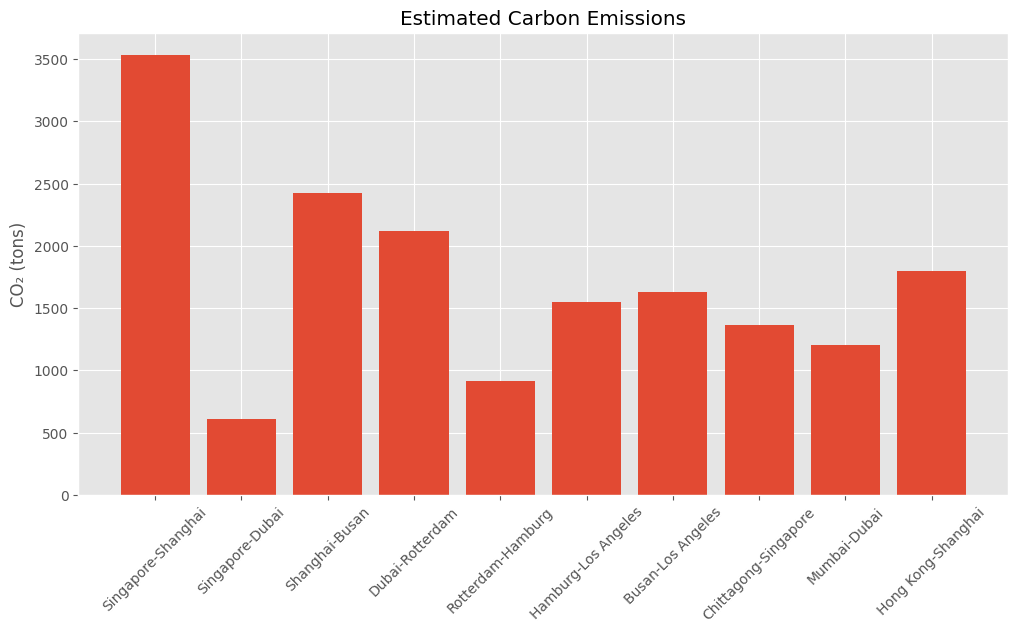

In [23]:
plt.figure(figsize=(12,6))

labels = (
    routes['Source']
    + "-"
    + routes['Target']
)

plt.bar(
    labels,
    routes['CO2_Tons']
)

plt.xticks(rotation=45)

plt.title(
    "Estimated Carbon Emissions"
)

plt.ylabel("CO₂ (tons)")

plt.show()

In [24]:
green_routes = routes.sort_values(
    "CO2_Tons"
)

green_routes.head()

,Source,Target,Cargo_TEU,Distance_km,CO2_Tons
1,Singapore,Dubai,10000,3026,605.20
4,Rotterdam,Hamburg,7500,6081,912.15
8,Mumbai,Dubai,5500,10905,1199.55
7,Chittagong,Singapore,5000,13645,1364.50
5,Hamburg,Los Angeles,6000,12920,1550.40


In [25]:
ports['Risk'] = np.random.uniform(
    0.2,
    1,
    len(ports)
)

ports['Vulnerability'] = (
    ports['Risk']
    *
    ports['Congestion']
)

ports[['Port',
       'Vulnerability']]

,Port,Vulnerability
0,Singapore,45.144143
1,Shanghai,20.501874
2,Rotterdam,13.679236
3,Dubai,41.542837
4,Los Angeles,55.630740
5,Hamburg,60.801281
6,Busan,25.156648
7,Chittagong,21.305976
8,Mumbai,56.338608
9,Hong Kong,49.287990


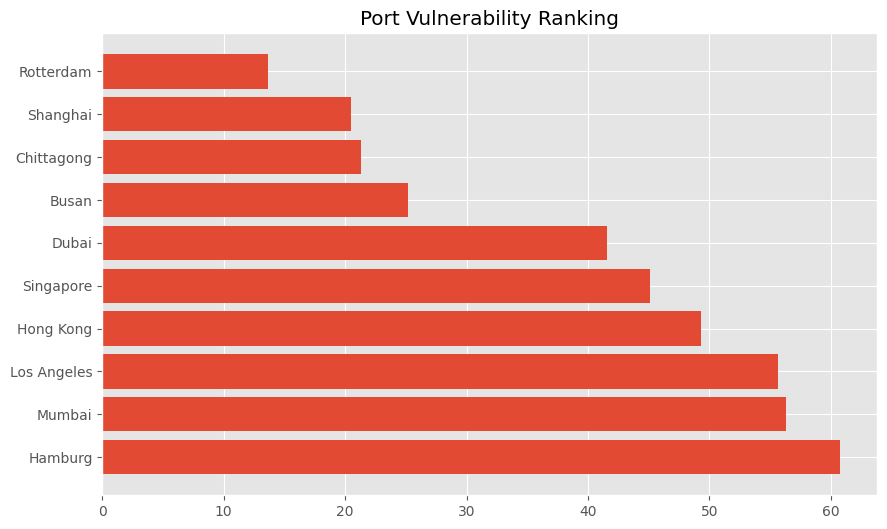

In [26]:
vul = ports.sort_values(
    "Vulnerability",
    ascending=False
)

plt.figure(figsize=(10,6))

plt.barh(
    vul['Port'],
    vul['Vulnerability']
)

plt.title(
    "Port Vulnerability Ranking"
)

plt.show()

In [27]:
G_test = G.copy()

G_test.remove_node(
    'Singapore'
)

print(
    "Connected Components:",
    nx.number_connected_components(
        G_test
    )
)

Connected Components: 2


In [28]:
critical_ports = [
    'Singapore',
    'Shanghai',
    'Dubai'
]

for port in critical_ports:

    temp = G.copy()

    temp.remove_node(port)

    print(
        port,
        nx.number_connected_components(
            temp
        )
    )

Singapore 2
Shanghai 2
Dubai 2


In [29]:
strategic = pd.DataFrame({
    'Port':degree_df['Port']
})

strategic['Degree'] = (
    degree_df['Centrality']
    .values
)

strategic['Betweenness'] = (
    bet_df['Betweenness']
    .values
)

strategic['Score'] = (
    strategic['Degree']
    +
    strategic['Betweenness']
)

strategic.sort_values(
    'Score',
    ascending=False
).head()

,Port,Degree,Betweenness,Score
0,Singapore,0.333333,0.444444,0.777778
1,Shanghai,0.333333,0.388889,0.722222
2,Dubai,0.333333,0.388889,0.722222
3,Busan,0.222222,0.166667,0.388889
4,Rotterdam,0.222222,0.166667,0.388889


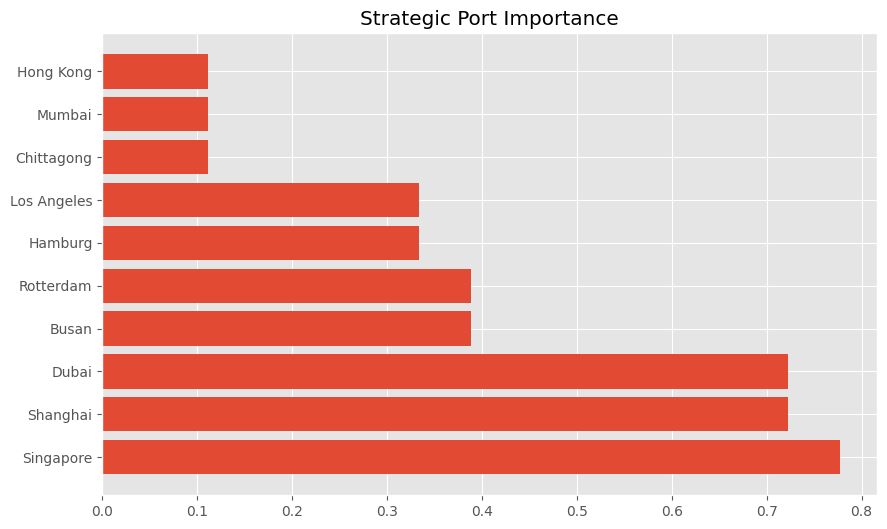

In [30]:
top_ports = strategic.sort_values(
    'Score',
    ascending=False
)

plt.figure(figsize=(10,6))

plt.barh(
    top_ports['Port'],
    top_ports['Score']
)

plt.title(
    "Strategic Port Importance"
)

plt.show()

In [31]:
print("="*50)

print(
    "GLOBAL MARITIME SHIPPING NETWORK ANALYTICS"
)

print("="*50)

print(
    "Total Ports:",
    G.number_of_nodes()
)

print(
    "Total Routes:",
    G.number_of_edges()
)

print(
    "Top Strategic Port:",
    top_ports.iloc[0]['Port']
)

print(
    "Highest Vulnerability:",
    vul.iloc[0]['Port']
)

print(
    "Largest Cargo Route:"
)

display(
    routes.sort_values(
        'Cargo_TEU',
        ascending=False
    ).head(1)
)

GLOBAL MARITIME SHIPPING NETWORK ANALYTICS
Total Ports: 10
Total Routes: 10
Top Strategic Port: Singapore
Highest Vulnerability: Hamburg
Largest Cargo Route:


,Source,Target,Cargo_TEU,Distance_km,CO2_Tons
0,Singapore,Shanghai,12000,14724,3533.76
